# Analisis Estadistico del Banco de Instancias

Notebook sincronizado con `notebooks/01_instance_analysis.py`.

Este notebook ejecuta el pipeline estadistico completo de Fase 3 y regenera las figuras en `notebooks/figures/`.


In [8]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    os.chdir(ROOT.parent)

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Working directory: {ROOT}")

Working directory: c:\Users\facem\OneDrive\Documentos\Maestría\OBC


In [9]:
import importlib.util

script_path = ROOT / "notebooks" / "01_instance_analysis.py"
spec = importlib.util.spec_from_file_location("instance_analysis", script_path)
instance_analysis = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(instance_analysis)

print(f"Script cargado: {script_path}")

Script cargado: c:\Users\facem\OneDrive\Documentos\Maestría\OBC\notebooks\01_instance_analysis.py


## Ejecutar analisis completo

In [10]:
instance_analysis.main()

Analisis estadistico del banco de instancias - Sprint 3.3
Instancias en catalogo: 15
Perfiles: ['industrial', 'large', 'medium', 'small', 'toy']
Seeds: [42, 123, 456]
Chequeo rapido: 15 instancias, 6 con Z* CBC, 6 con tiempo CBC.

Generando graficas...
  Guardado: notebooks\figures\demand_histograms.png
  Guardado: notebooks\figures\demand_by_period.png
  Guardado: notebooks\figures\instance_catalog_overview.png
  Guardado: notebooks\figures\optimal_solutions.png
  Guardado: notebooks\figures\demand_correlation_heatmaps.png

Nombre                 Perfil       F   T    W  Demand mu    CV     Z* (M)   t(s)
----------------------------------------------------------------------------------------------------------
toy_seed42             toy          3   4    5    2,486.8 0.481      269.1   0.31
toy_seed123            toy          3   4    5    2,615.8 0.460      276.3   0.10
toy_seed456            toy          3   4    5    2,581.0 0.490      282.8   0.15
small_seed42           small      

In [11]:
from pathlib import Path

fig_dir = ROOT / "notebooks" / "figures"
for p in sorted(fig_dir.glob("*.png")):
    print(f"{p.name:32} {p.stat().st_size:>10} bytes")

demand_by_period.png                 225447 bytes
demand_correlation_heatmaps.png      172990 bytes
demand_histograms.png                256269 bytes
instance_catalog_overview.png        174110 bytes
optimal_solutions.png                129691 bytes


## Vista rapida de figuras

demand_histograms.png


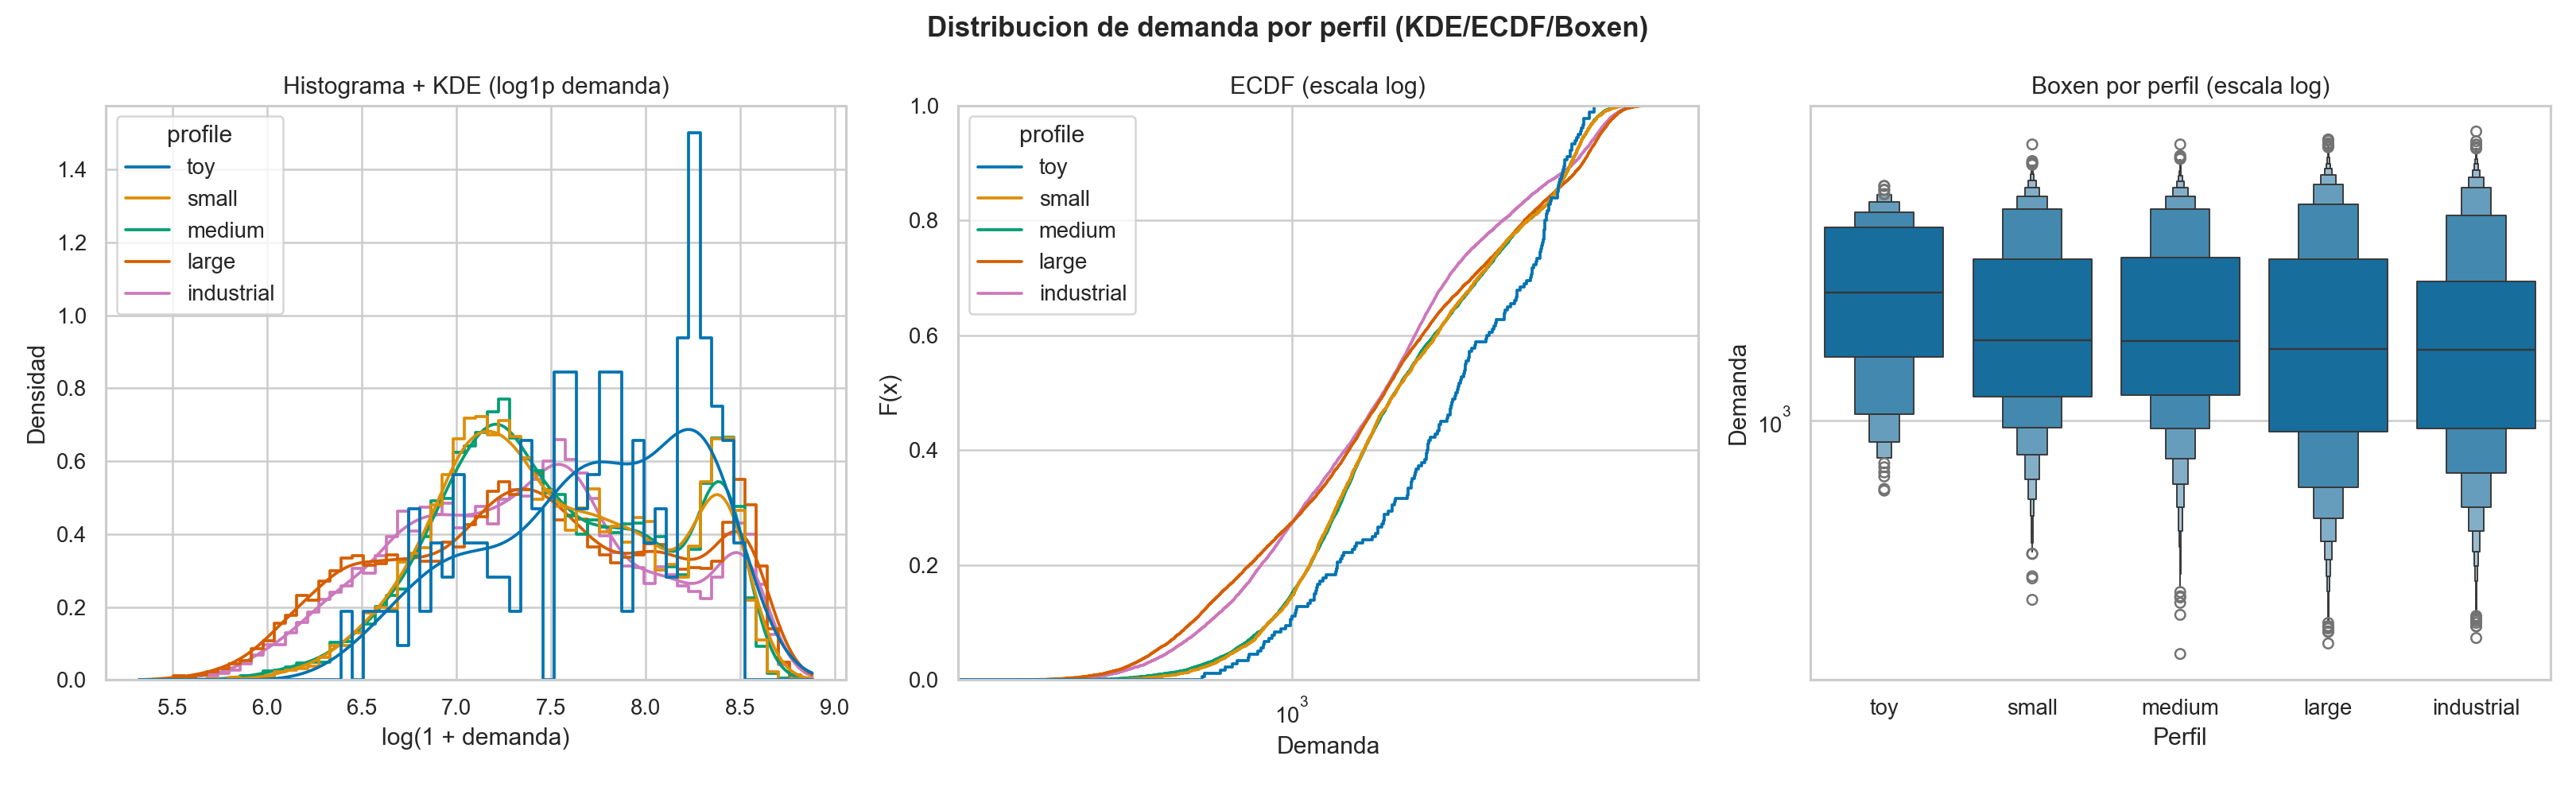

demand_by_period.png


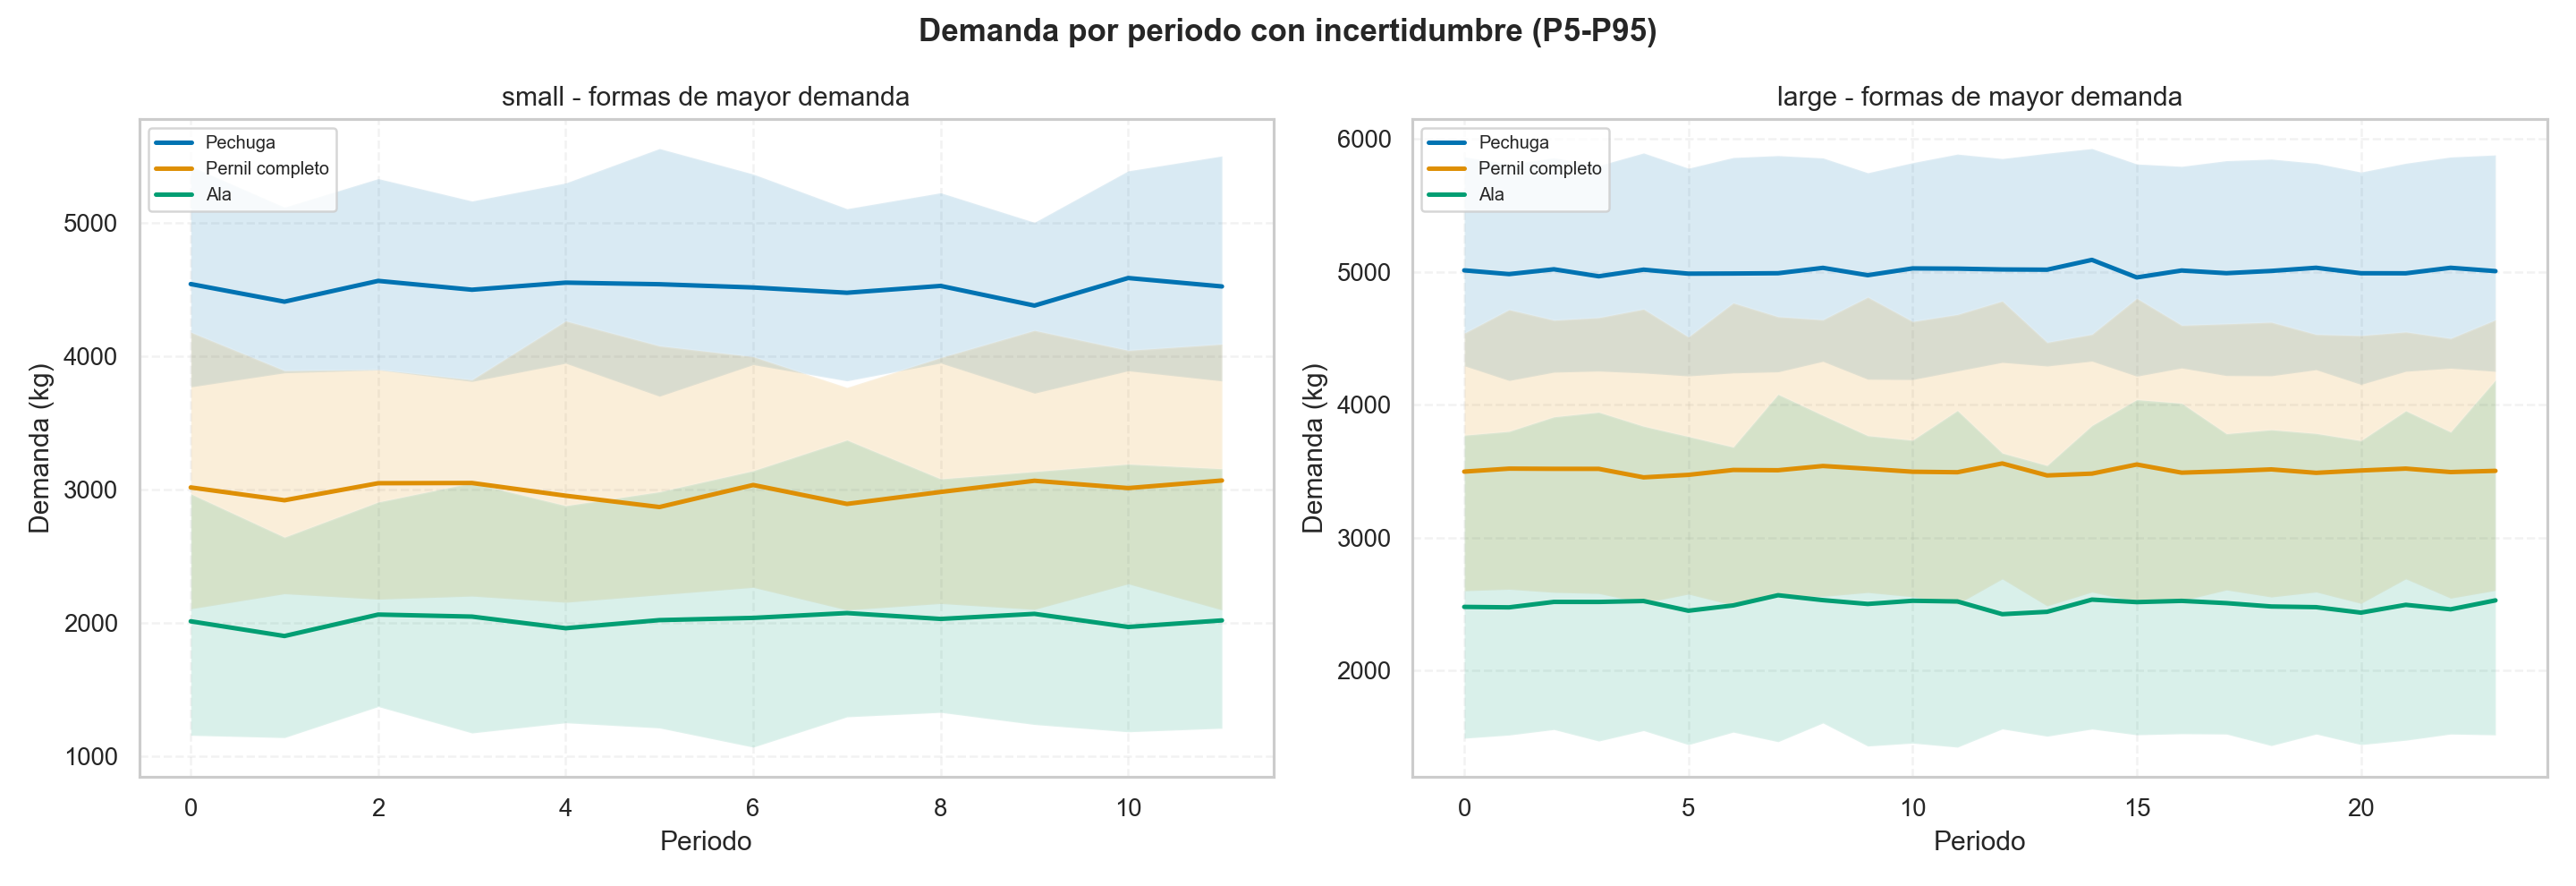

instance_catalog_overview.png


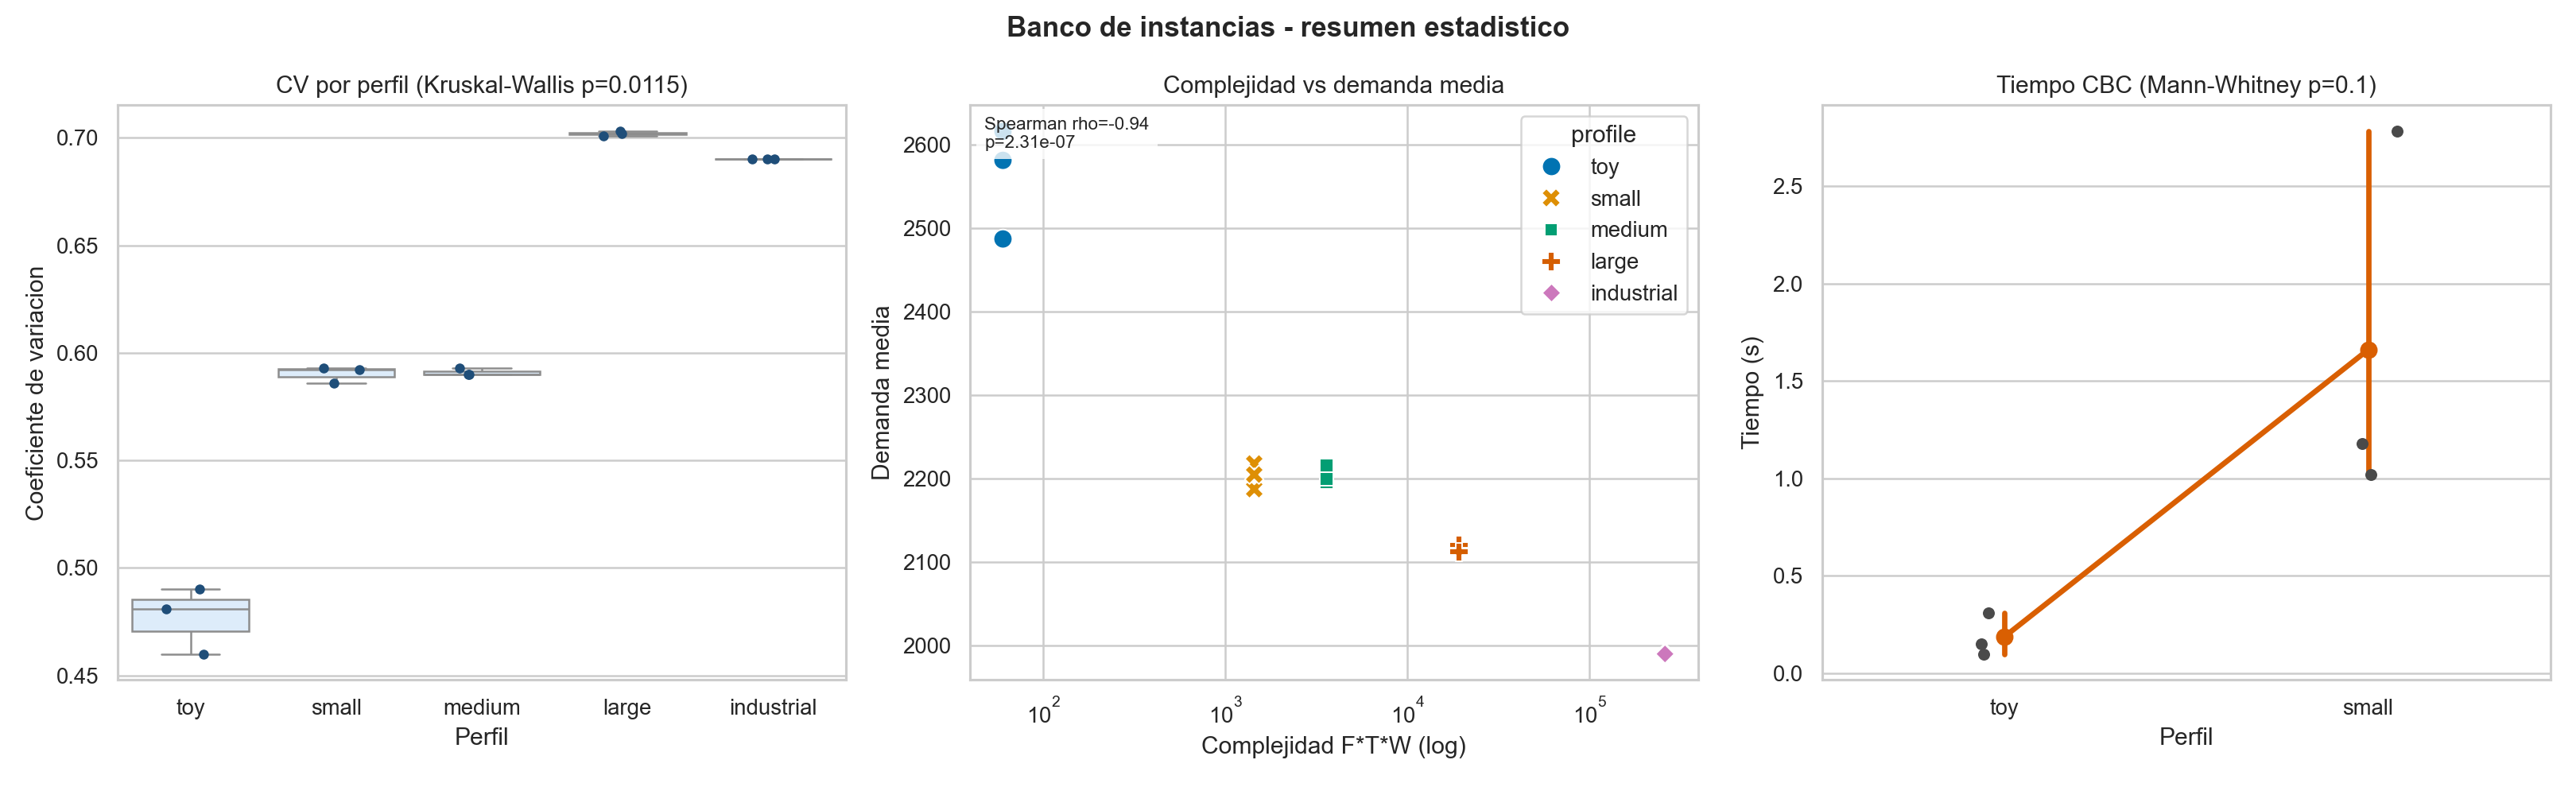

optimal_solutions.png


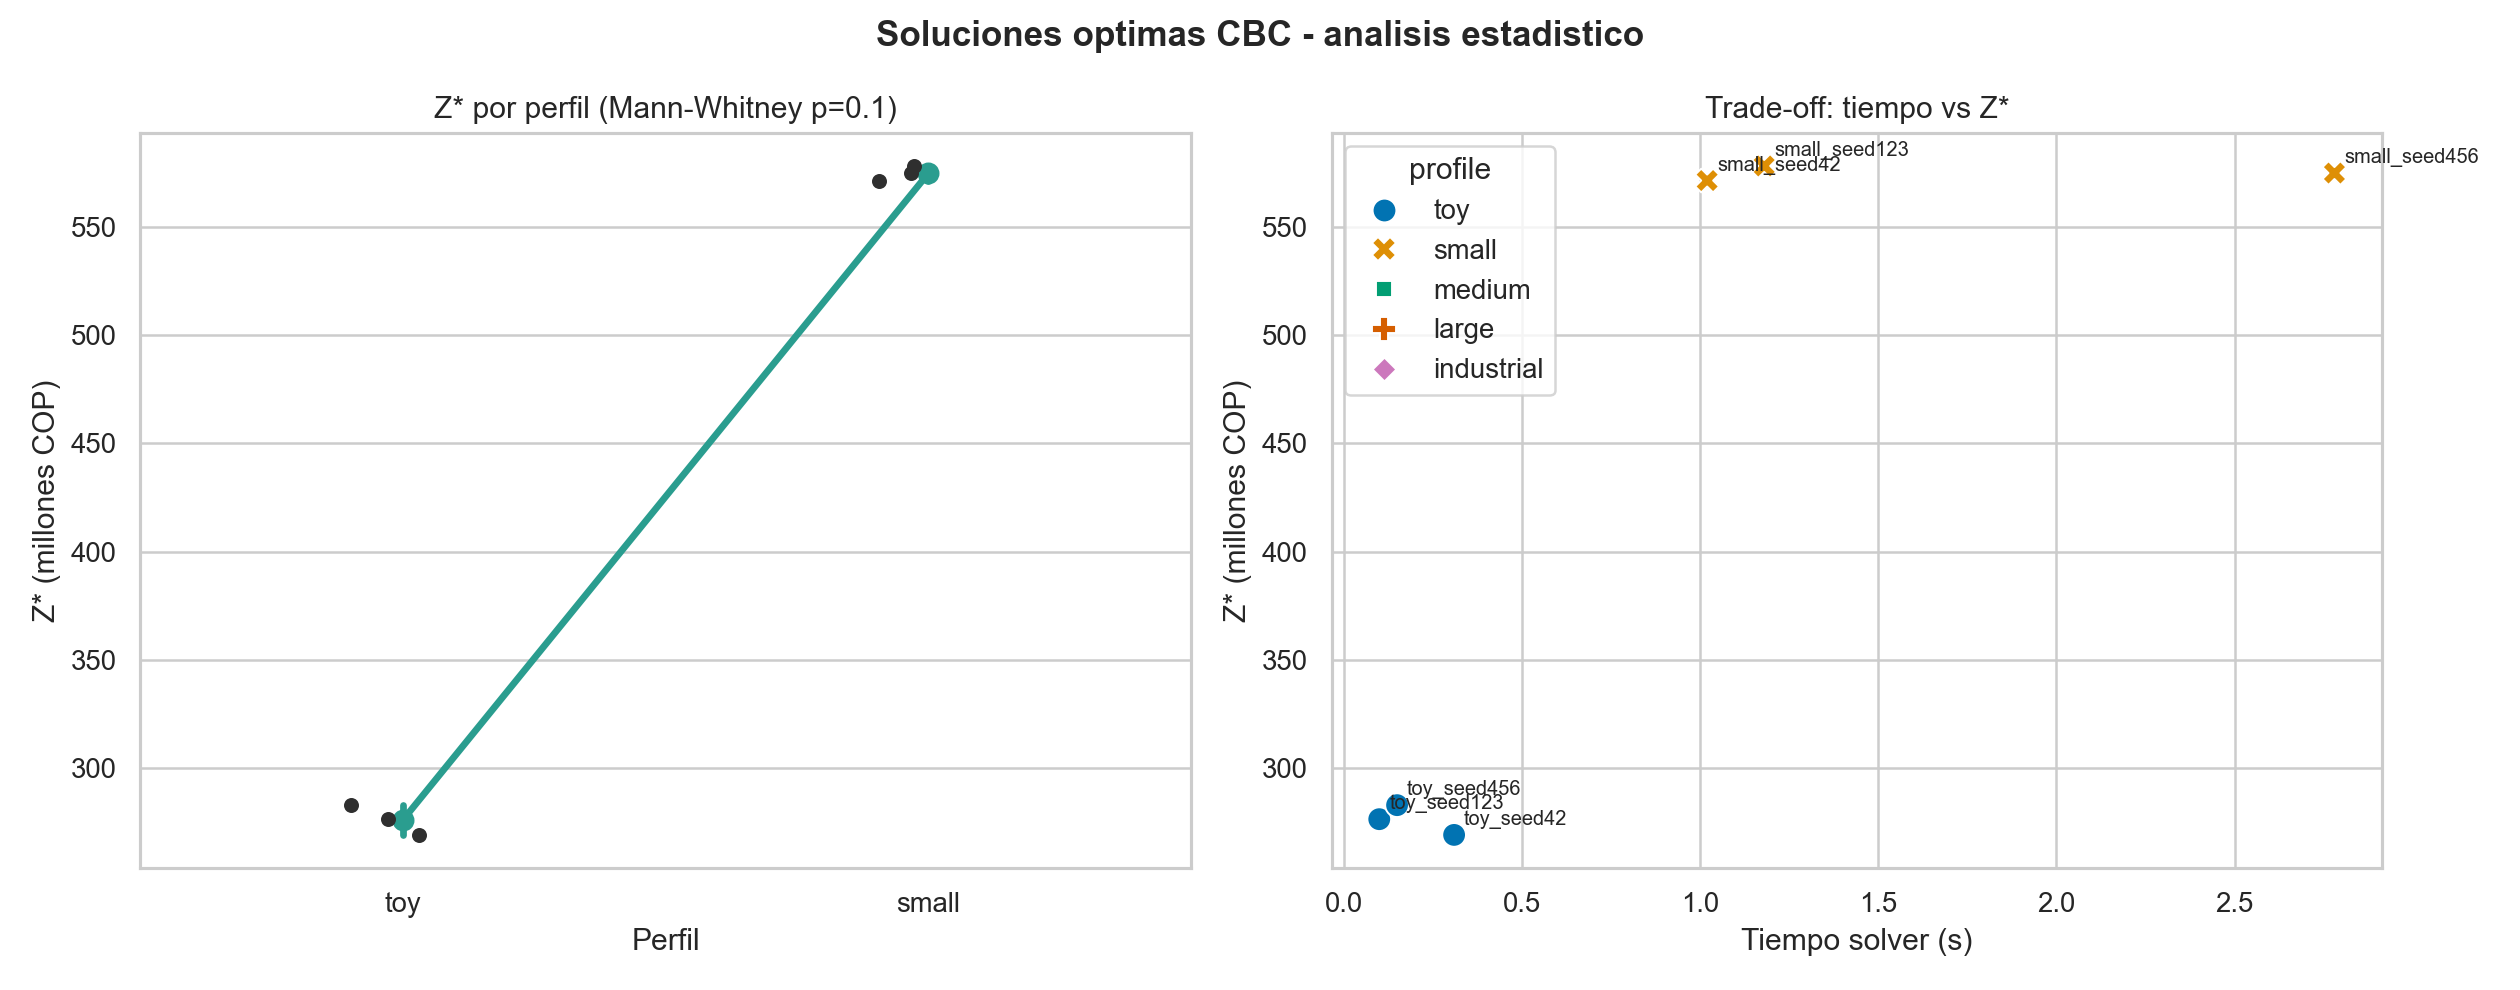

demand_correlation_heatmaps.png


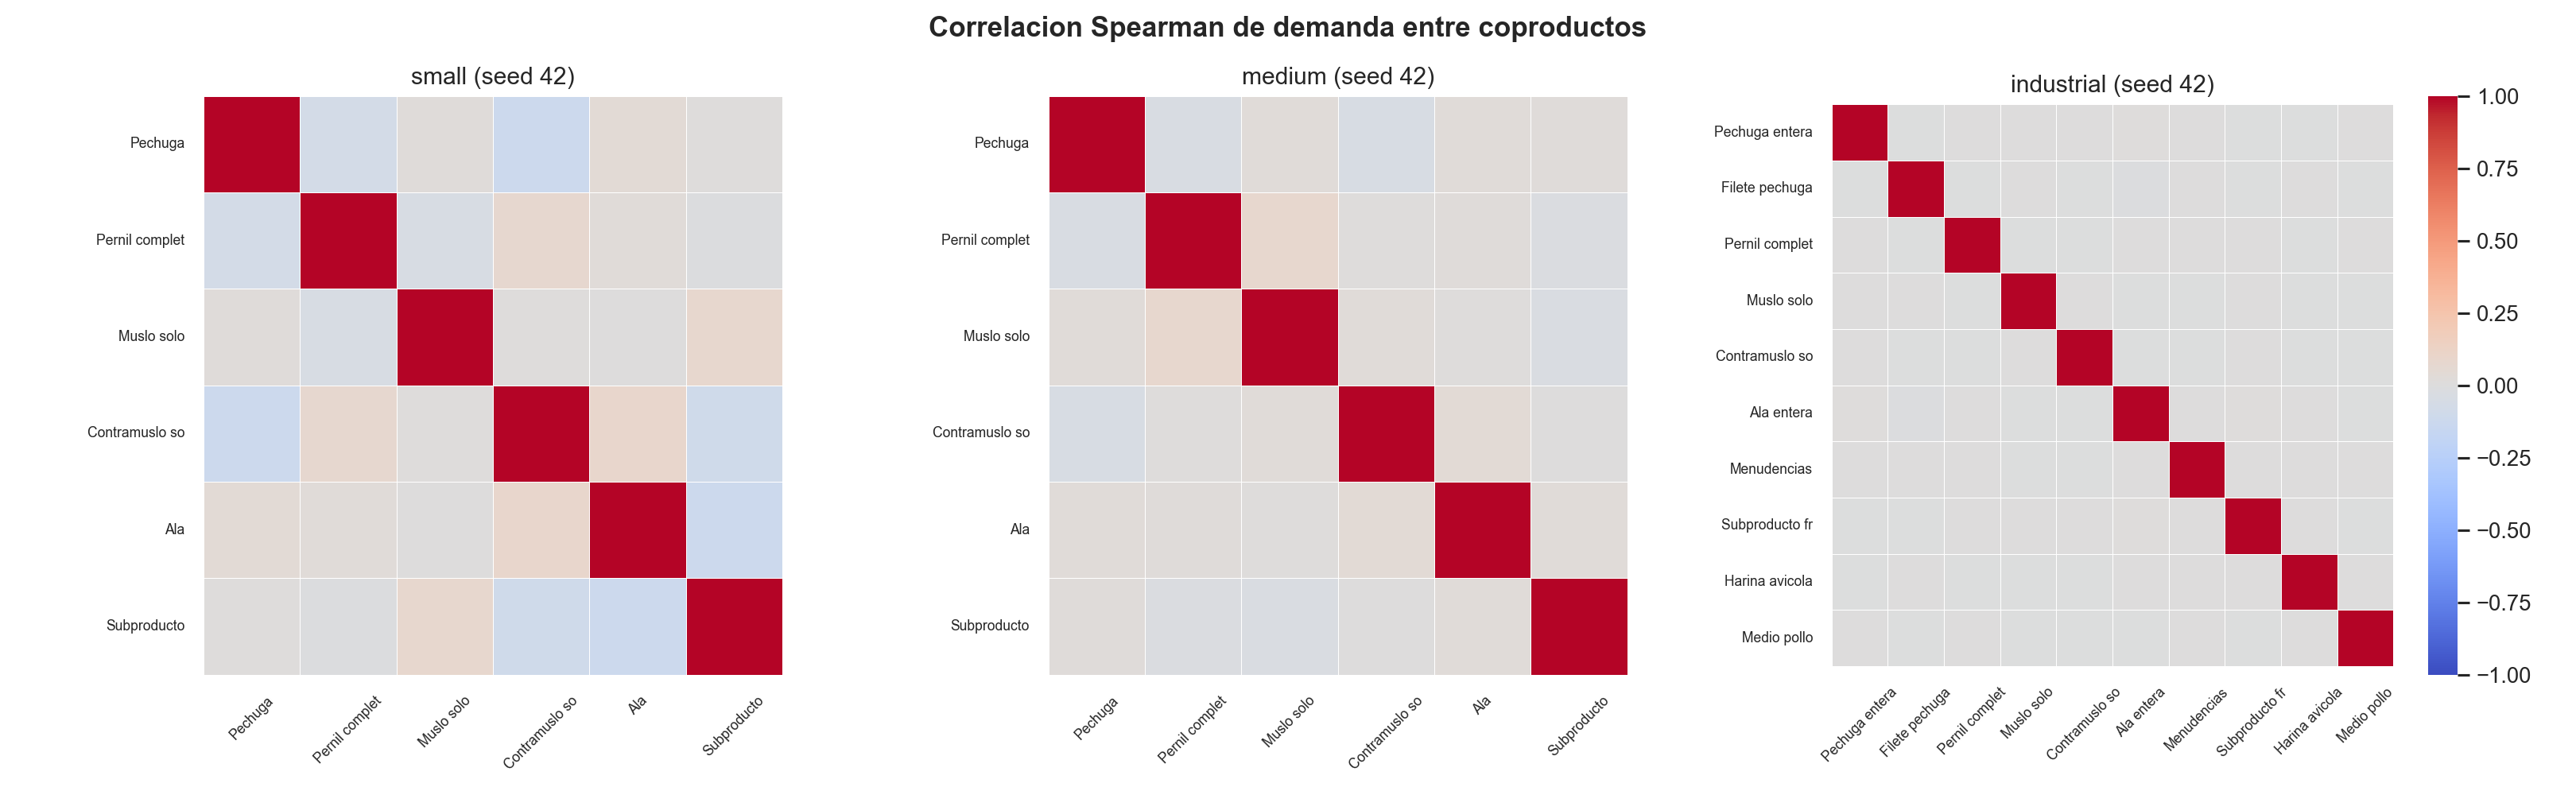

: 

In [ ]:
from IPython.display import Image, display

preview = [
    "demand_histograms.png",
    "demand_by_period.png",
    "instance_catalog_overview.png",
    "optimal_solutions.png",
    "demand_correlation_heatmaps.png",
]

for name in preview:
    p = ROOT / "notebooks" / "figures" / name
    if p.exists():
        print(name)
        display(Image(filename=str(p), width=900))
    else:
        print(f"No encontrado: {name}")